# b) Use KNN to predict house prices for the dataset you used in exercise1 


In [1293]:
import pandas as pd

df = pd.read_csv("../../data/data.csv")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [1294]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [1295]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [1296]:
df["street"].unique()

array(['18810 Densmore Ave N', '709 W Blaine St',
       '26206-26214 143rd Ave SE', ..., '759 Ilwaco Pl NE',
       '5148 S Creston St', '18717 SE 258th St'],
      shape=(4525,), dtype=object)

In [1297]:
df["country"].value_counts()

country
USA    4600
Name: count, dtype: int64

In [1298]:
# categorical feature that is one-hot encoded - 0 or 1
df["waterfront"].value_counts()

waterfront
0    4567
1      33
Name: count, dtype: int64

In [1299]:
# drop categorical features and less correlated values

df = df.drop(["date", "street", "city", "statezip", "country", "condition", "waterfront", "floors"], axis="columns")#"sqft_lot", "condition", "yr_built", "yr_renovated"
df.head()



,price,bedrooms,bathrooms,sqft_living,sqft_lot,view,sqft_above,sqft_basement,yr_built,yr_renovated
0,313000.0,3.0,1.50,1340,7912,0,1340,0,1955,2005
1,2384000.0,5.0,2.50,3650,9050,4,3370,280,1921,0
2,342000.0,3.0,2.00,1930,11947,0,1930,0,1966,0
3,420000.0,3.0,2.25,2000,8030,0,1000,1000,1963,0
4,550000.0,4.0,2.50,1940,10500,0,1140,800,1976,1992


In [1300]:
# inspecting values looking for 0 and extreme outliers
df["price"].sort_values().min()

np.float64(0.0)

In [1301]:
# remove all 0 vals in price
df = df[df["price"] > 0]

In [1302]:
df["price"].describe().T

count    4.551000e+03
mean     5.579059e+05
std      5.639299e+05
min      7.800000e+03
25%      3.262643e+05
50%      4.650000e+05
75%      6.575000e+05
max      2.659000e+07
Name: price, dtype: float64

In [1303]:
# calculating upper and lower limits by percentiles and filtering out the outliers
lower_limit = df["price"].quantile(0.01)
upper_limit = df["price"].quantile(0.99)

df_no_outliers = df[(df["price"] >= lower_limit) & (df["price"] <= upper_limit)]

print(f"rows after filtering: {df_no_outliers.shape[0]} rows")
print(f"lower : {lower_limit:,.0f}  |  upper: {upper_limit:,.0f}")

rows after filtering: 4460 rows
lower : 148,000  |  upper: 2,016,000


In [1304]:
df_no_outliers["price"].describe().T

count    4.460000e+03
mean     5.328763e+05
std      2.893115e+05
min      1.480000e+05
25%      3.299000e+05
50%      4.650000e+05
75%      6.500000e+05
max      2.005000e+06
Name: price, dtype: float64

In [1305]:
# tried with  dummies to explore the importance of the different conditions
# df_no_outliers = pd.get_dummies(df_no_outliers, columns=["condition"], prefix="cond")
# # df.head()

In [1306]:
X, y = df_no_outliers.drop("price", axis = "columns"), df_no_outliers["price"]
X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,view,sqft_above,sqft_basement,yr_built,yr_renovated
0,3.0,1.50,1340,7912,0,1340,0,1955,2005
2,3.0,2.00,1930,11947,0,1930,0,1966,0
3,3.0,2.25,2000,8030,0,1000,1000,1963,0
4,4.0,2.50,1940,10500,0,1140,800,1976,1992
5,2.0,1.00,880,6380,0,880,0,1938,1994


<Axes: >

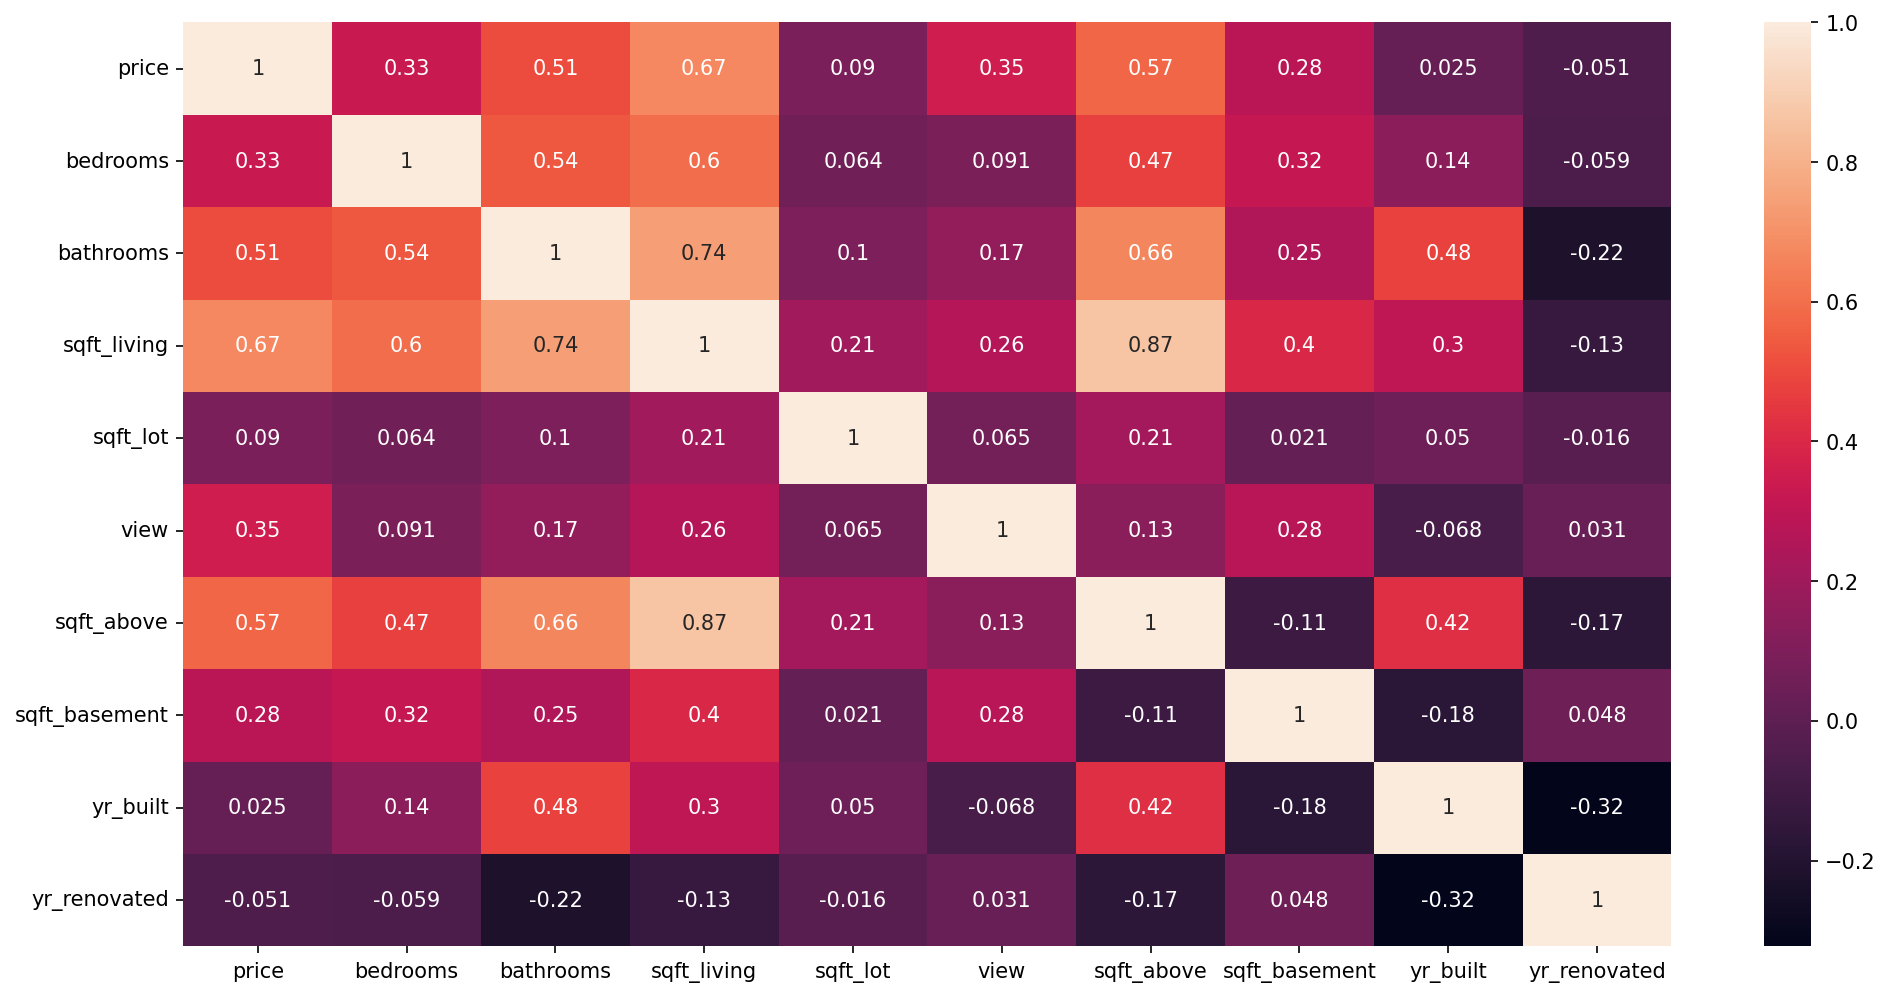

In [1308]:
import matplotlib.pyplot as plt
import seaborn as sns

fig,ax = plt.subplots(1, figsize=(16,8), dpi=150)

sns.heatmap(df_no_outliers.corr(numeric_only=True), annot=True)

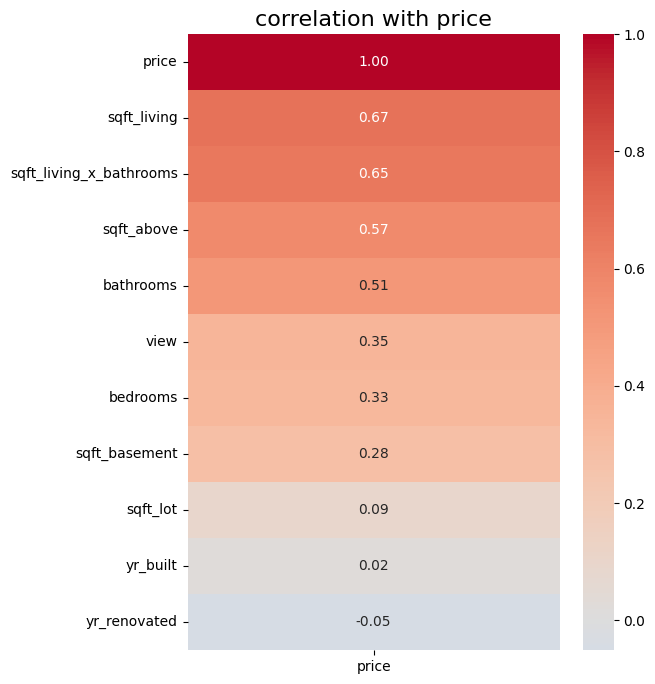

In [1309]:
# merge X and y temporary
df_with_price = X.copy()
df_with_price["price"] = y

# Calc correlations. sort by price
corr_price = df_with_price.corr(numeric_only=True)[["price"]].sort_values(
    by="price", ascending=False
)

# visualize
plt.figure(figsize=(6, 8))
sns.heatmap(corr_price, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("correlation with price", fontsize=16)
plt.show()

In [1310]:
# # removing categorical and lesser correlation features
# df_feature_select = df.drop(
#     ["sqft_lot", "condition", "yr_built", "yr_renovated"], axis="columns"
# )  # view?
# df_feature_select.head()

In [1311]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

X_train.shape, X_test.shape

((2988, 10), (1472, 10))

In [1312]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import numpy as np


def standard(X_train, X_test, verbose=False):
    scaler = StandardScaler()
    scaler.fit(X_train)

    scaled_X_train = scaler.transform(X_train)
    scaled_X_test = scaler.transform(X_test)

    if verbose:
        print("Train min:", np.min(scaled_X_train), "max:", np.max(scaled_X_train))
        print("Test min:", np.min(scaled_X_test), "max:", np.max(scaled_X_test))

    return scaled_X_train, scaled_X_test


In [1313]:

def minMax(X_train, X_test, verbose=False):
    scaler = MinMaxScaler()
    scaler.fit(X_train)
    scaled_X_train = scaler.transform(X_train) 
    scaled_X_test = scaler.transform(X_test) 
    
    if verbose:
        print("Train min:", np.min(scaled_X_train), "max:", np.max(scaled_X_train))
        print("Test min:", np.min(scaled_X_test), "max:", np.max(scaled_X_test))

    return scaled_X_train, scaled_X_test

scaled_X_train, scaled_X_test = minMax(X_train, X_test, verbose=True)

Train min: 0.0 max: 1.0
Test min: 0.0 max: 2.2476290170627027


                   Feature  Importance
2              sqft_living    0.511998
7                 yr_built    0.114182
3                 sqft_lot    0.095793
9  sqft_living_x_bathrooms    0.087723
5               sqft_above    0.062416
4                     view    0.039189
8             yr_renovated    0.024560
6            sqft_basement    0.024253
0                 bedrooms    0.023754
1                bathrooms    0.016132


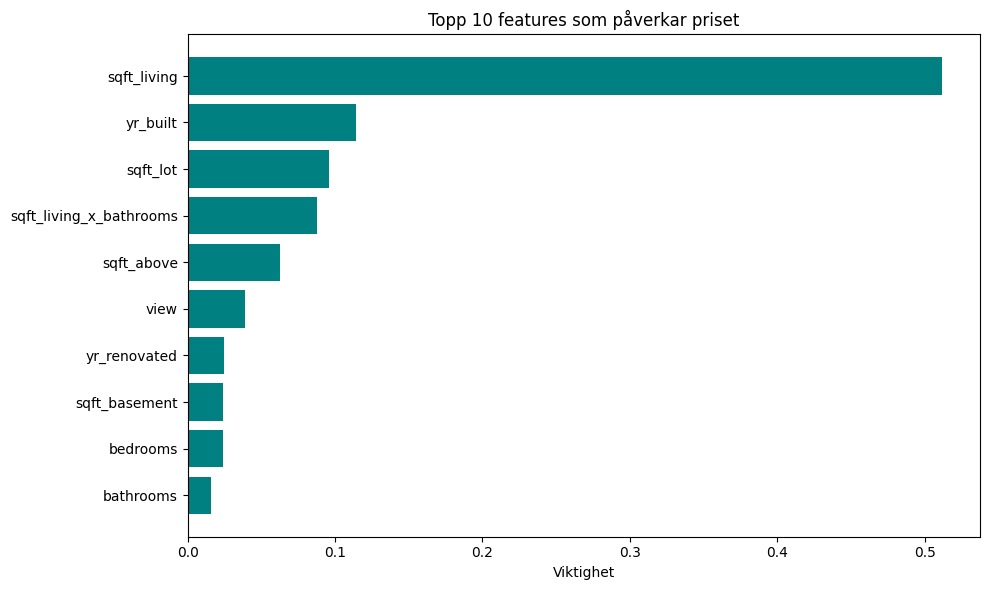

In [1314]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt

# Träna en Random Forest-modell
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(scaled_X_train, y_train)

# Hämta feature importance
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Skapa DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Visa topp 10
print(importance_df.head(16))

# 📊 Visualisera
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:10][::-1], importance_df['Importance'][:10][::-1], color='teal')
plt.xlabel("Viktighet")
plt.title("Topp 10 features som påverkar priset")
plt.tight_layout()

In [1315]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=10) # check what value is best?
model.fit(scaled_X_train, y_train)

y_pred = model.predict(scaled_X_test)
y_pred[:10]

array([473700.       , 615886.5333333, 597625.6      , 873530.       ,
       382105.       , 689470.       , 420771.25     , 379820.       ,
       424095.       , 270428.8      ])

In [1316]:
y_test.values[:10]

array([ 409500.,  852600.,  279000.,  810000.,  183000.,  400000.,
        620000.,  350000., 1034500.,  398000.])

In [1317]:
# evaluate minmaxscale model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")


MAE: 142877.73
MSE: 39615135812.06
RMSE: 199035.51
R²: 0.48


In [1318]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

best_k = None
best_mae = float('inf')

neighbors_range = range(1, 21)

for k in neighbors_range:
    model = KNeighborsRegressor(n_neighbors=k)
    mae_scores = cross_val_score(model, scaled_X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    mean_mae = -mae_scores.mean()

    print(f"k={k} → MAE: {mean_mae:.2f}")

    if mean_mae < best_mae:
        best_mae = mean_mae
        best_k = k

print(f"\n✅ Bästa k: {best_k} med MAE: {best_mae:.2f}")

# 🚀 Träna slutmodell med bästa k
final_model = KNeighborsRegressor(n_neighbors=best_k)
final_model.fit(scaled_X_train, y_train)
y_pred = final_model.predict(scaled_X_test)

# 📊 Utvärdera slutmodell
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n📈 Slutmodellens prestanda på testdata:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

k=1 → MAE: 190218.36
k=2 → MAE: 164744.53
k=3 → MAE: 157091.47
k=4 → MAE: 153413.82
k=5 → MAE: 150863.28
k=6 → MAE: 149604.31
k=7 → MAE: 147774.66
k=8 → MAE: 147234.00
k=9 → MAE: 146565.16
k=10 → MAE: 145871.22
k=11 → MAE: 146244.01
k=12 → MAE: 145904.63
k=13 → MAE: 146239.48
k=14 → MAE: 146242.15
k=15 → MAE: 146204.01
k=16 → MAE: 146185.70
k=17 → MAE: 146002.58
k=18 → MAE: 146248.55
k=19 → MAE: 146382.57
k=20 → MAE: 146599.44

✅ Bästa k: 10 med MAE: 145871.22

📈 Slutmodellens prestanda på testdata:
MAE: 142877.73
MSE: 39615135812.06
RMSE: 199035.51
R²: 0.48


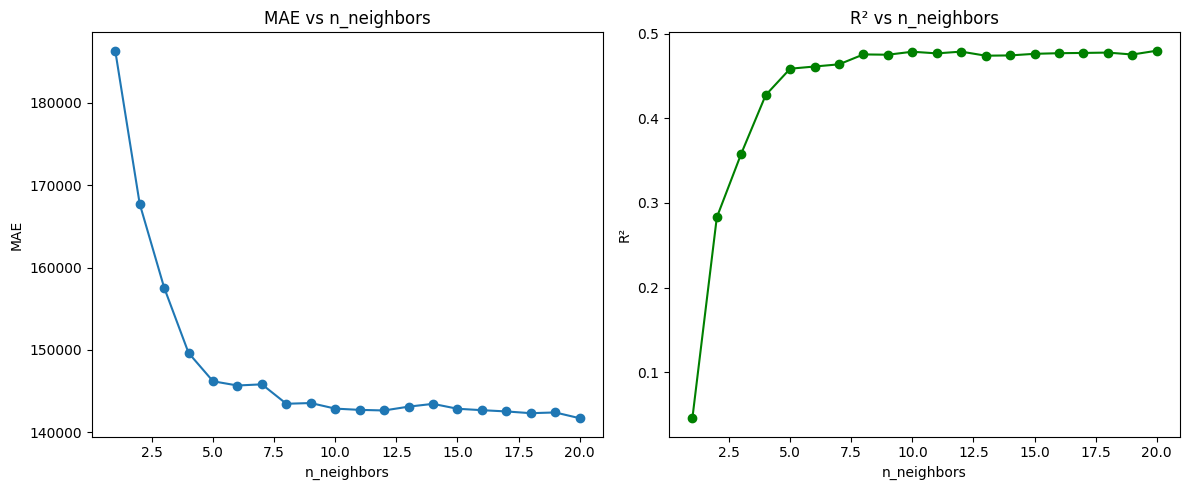

In [1319]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

mae_scores = []
r2_scores = []
neighbors_range = range(1, 21)  # Testa k från 1 till 20

for k in neighbors_range:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(scaled_X_train, y_train)
    y_pred = model.predict(scaled_X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    mae_scores.append(mae)
    r2_scores.append(r2)

# 📊 Visualisera resultaten
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(neighbors_range, mae_scores, marker='o')
plt.title("MAE vs n_neighbors")
plt.xlabel("n_neighbors")
plt.ylabel("MAE")

plt.subplot(1, 2, 2)
plt.plot(neighbors_range, r2_scores, marker='o', color='green')
plt.title("R² vs n_neighbors")
plt.xlabel("n_neighbors")
plt.ylabel("R²")

plt.tight_layout()

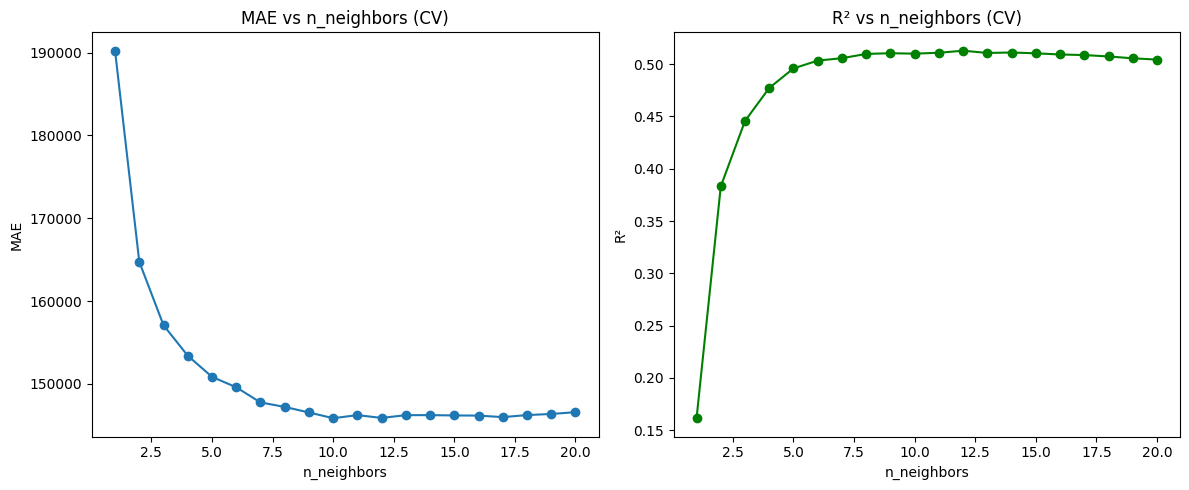

In [1320]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

mae_scores = []
r2_scores = []
neighbors_range = range(1, 21)

# Skapa egna scorers för MAE och R²
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

for k in neighbors_range:
    model = KNeighborsRegressor(n_neighbors=k)
    
    # MAE (negativt eftersom sklearn maximerar scorers)
    mae = cross_val_score(model, scaled_X_train, y_train, cv=5, scoring=mae_scorer)
    r2 = cross_val_score(model, scaled_X_train, y_train, cv=5, scoring=r2_scorer)
    
    mae_scores.append(-mae.mean())  # ta bort minus för att visa positiv MAE
    r2_scores.append(r2.mean())

# 📊 Visualisera
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(neighbors_range, mae_scores, marker='o')
plt.title("MAE vs n_neighbors (CV)")
plt.xlabel("n_neighbors")
plt.ylabel("MAE")

plt.subplot(1, 2, 2)
plt.plot(neighbors_range, r2_scores, marker='o', color='green')
plt.title("R² vs n_neighbors (CV)")
plt.xlabel("n_neighbors")
plt.ylabel("R²")

plt.tight_layout()
plt.show()

In [1321]:
scaled_X_train, scaled_X_test = standard(X_train, X_test)
model = KNeighborsRegressor(n_neighbors=1) # kolla vilken int
model.fit(scaled_X_train, y_train)

y_pred = model.predict(scaled_X_test)
y_pred[:10]

array([ 323000.      ,  402000.      ,  327000.      ,  760000.      ,
        352500.      , 1150000.      ,  575000.      ,  259585.571429,
        439950.      ,  306888.      ])

In [1322]:
y_test.values[:10]

array([ 409500.,  852600.,  279000.,  810000.,  183000.,  400000.,
        620000.,  350000., 1034500.,  398000.])

In [1323]:
# evaluate standardscale model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

MAE: 189046.01
MSE: 74792278928.27
RMSE: 273481.77
R²: 0.02
